In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.stats import sigma_clip
from scipy.stats import binned_statistic

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



776 SNe before paper-based quality cuts.
579 SNe after paper-based quality cuts.


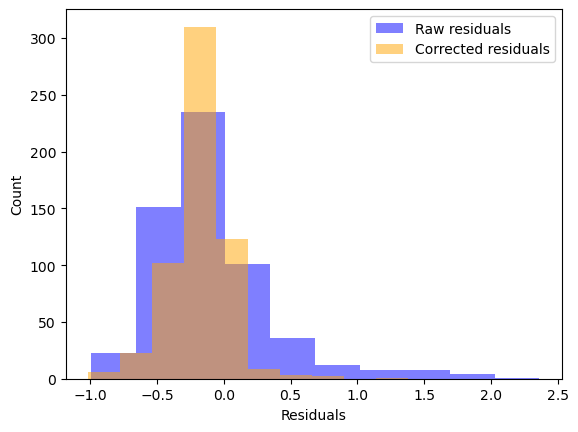

Raw scatter: 0.4519279752197204
Scatter after linear x1 and c correction: 0.20830115303169483


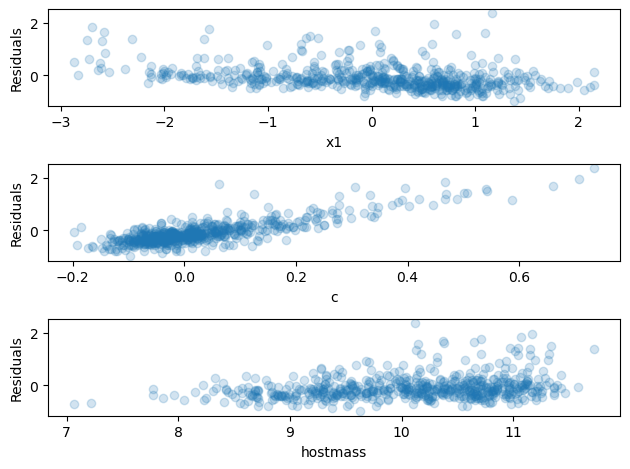

In [9]:

# =====================================================
# Read in FIRST dataset
# =====================================================

df = pd.read_csv(
    "ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv"
)

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df), "SNe before paper-based quality cuts.")
df = df[(df["lccoverage_flag"] == 1) & (df["fitquality_flag"] == 1)]
print(len(df), "SNe after paper-based quality cuts.")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df["SDSS_g_minus_r"] = df["ABSMAG01_SDSS_G"] - df["ABSMAG01_SDSS_R"]

# Read the Error Collumn for the distance modulus measurements.
yerr_all = df["sigma_mu_meas"]

nbins = 10


# =====================================================
# PI TOY-TEMPLATE SECTION (STOP HERE)
#   - Build dmu_raw from your dataset
#   - Build dmu_corr by linear x1,c correction
#   - Histograms + scatter vs x1, c, hostmass
# =====================================================

# =====================================================
# -----------------------------
# 2) Choose target we're trying to predict + features that will be used in training
# -----------------------------
# =====================================================
target_col = "residual_centered"

feature_cols = [
    "LOGMSTAR",
    "SFR",
    "VDISP",
    "DN4000",
    "SDSS_g_minus_r",
    "AGE",
    "x1",
    "c"
]

# Building table that ends up selecting only the feature_cols
# and target_col from the data frame we read "df"
df_model = df[feature_cols + [target_col]].copy()

# ---- This is your "raw" Hubble residuals analog (toy dmu_raw) ----
# In the no_x1_c file, residual_centered is uncorrected for x1 and c.
dmu_raw = df_model[target_col].to_numpy()

# ---- Compute a linear correction from your data (like toy alpha/beta) ----
# Fit: dmu_raw ≈ b0 + b1*x1 + b2*c
mask_lin = (
    np.isfinite(df_model["x1"]) &
    np.isfinite(df_model["c"]) &
    np.isfinite(df_model[target_col])
)

X_lin = np.column_stack([
    np.ones(np.sum(mask_lin)),
    df_model.loc[mask_lin, "x1"].to_numpy(),
    df_model.loc[mask_lin, "c"].to_numpy()
])
y_lin = df_model.loc[mask_lin, target_col].to_numpy()

# Least squares coefficients (data-driven)
b0, b1, b2 = np.linalg.lstsq(X_lin, y_lin, rcond=None)[0]

# ---- This is your "corrected" residuals analog (toy dmu_corr) ----
# Toy: dmu_corr = dmu_raw + alpha*x1 - beta*c
# Here: subtract the fitted shows dependence on x1 and c
dmu_corr = np.full_like(dmu_raw, np.nan, dtype=float)
dmu_corr[mask_lin.to_numpy()] = y_lin - (b1 * df_model.loc[mask_lin, "x1"].to_numpy() + b2 * df_model.loc[mask_lin, "c"].to_numpy())

# COMPUTATIONS #
mean = np.nanmean(dmu_raw) # The mean of the raw Hubble residuals


plt.hist(dmu_raw[np.isfinite(dmu_raw)], alpha=0.5, color='blue', label='Raw residuals')
plt.hist(dmu_corr[np.isfinite(dmu_corr)], alpha=0.5, color='orange', label='Corrected residuals')
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.legend()
plt.show()


print("Raw scatter:", np.nanstd(dmu_raw))
print("Scatter after linear x1 and c correction:", np.nanstd(dmu_corr))

# Hubble residuals (uncorrected) vs SNIa light curve parameters and stuff:

plt.subplot(3,1,1)
plt.scatter(df_model["x1"], dmu_raw, alpha=0.2)
plt.xlabel('x1')
plt.ylabel('Residuals')

plt.subplot(3,1,2)
plt.scatter(df_model["c"], dmu_raw, alpha=0.2)
plt.xlabel('c')
plt.ylabel('Residuals')

plt.subplot(3,1,3)
plt.scatter(df_model["LOGMSTAR"], dmu_raw, alpha=0.2)
plt.xlabel('hostmass')  # LOGMSTAR is your host mass proxy
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

In [ ]:
Ca